# Part 1: Process Historical Weather and Climate Events


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install dotenv

In [ ]:
from dotenv import load_dotenv
from datetime import timedelta
import os
import numpy as np
import pandas as pd
import json
from openai import OpenAI

In [ ]:
## Get the API key from the environment

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

### Create a ClimateEventDataset Class to preprocess US Billion Weather and Climate Events dataset

In [ ]:
class ClimateEventDataset:
    def __init__(self, file_path):
        """
        Initializes the dataset by loading the data from a CSV file, cleaning it, and preparing it for later processing.
        """
        self.df = self._load_data(file_path)
        self.events_by_week = self._group_events_by_week()

    def _load_data(self, file_path):
        """
        Loads the CSV file and returns a cleaned DataFrame.
        """
        df = pd.read_csv(file_path)

        df['Begin Date'] = pd.to_datetime(df['Begin Date'], format='%Y%m%d', errors='coerce')
        df['End Date'] = pd.to_datetime(df['End Date'], format='%Y%m%d', errors='coerce')
        df['Summary'] = df['Summary'].fillna('')

        ''' invalid_dates = df[df['Begin Date'].isna() | df['End Date'].isna()]

        # Print the rows with invalid dates
        print("Rows with invalid or missing Begin Date or End Date:")
        print(invalid_dates)'''

        return df

    def _group_events_by_week(self):
        """
        Groups events by week, taking into account the fact that some events span multiple weeks.
        Returns a dictionary where the keys are week start dates (YYYY-MM-DD) and the values
        are DataFrames containing all events that occurred or continued in that week.
        """
        df = self.df.copy()

        # Create week ranges for grouping
        df['Begin Week'] = df['Begin Date'].dt.to_period('W-SUN').apply(lambda r: r.start_time)
        df['End Week'] = df['End Date'].dt.to_period('W-SUN').apply(lambda r: r.start_time)

        events_by_week = {}

        # Iterate through each row (event)
        for _, row in df.iterrows():
            start_week = row['Begin Week']
            end_week = row['End Week']

            # Add the event to each week it spans
            current_week = start_week
            #week_count = 1  # Track which week of the event's duration we are in, 1 = 1st week
            while current_week <= end_week:
                if current_week not in events_by_week:
                    events_by_week[current_week] = []
                # Append the event with the current duration week (e.g., 1st week, 2nd week)
                row_with_duration = row.copy()
                week_count = ((current_week - start_week).days // 7) + 1
                row_with_duration['Duration Week'] = week_count
                row_with_duration['Total Duration'] = (end_week - start_week).days// 7 + 1
                events_by_week[current_week].append(row_with_duration)
                current_week = (current_week.to_period('W-SUN') + 1).start_time


        for week in events_by_week:
            events_by_week[week] = pd.DataFrame(events_by_week[week])

        return events_by_week

    def get_events_for_week(self, week_start_date):
        """
        Retrieves all climate events that occurred in a specific week, starting from the given date (YYYY-MM-DD).
        This includes events that started or ended within the week.
        """
        week_start_date = pd.Timestamp(week_start_date)
        return self.events_by_week.get(week_start_date, pd.DataFrame())

    def prepare_gpt_input_for_week(self, week_start_date):
        """
        Prepares a comprehensive text input that includes event details (CPI-adjusted cost, deaths, summary, and duration)
        for all events in a given week. This input is then fed into GPT for feature extraction.
        """
        events = self.get_events_for_week(week_start_date)
        if events.empty:
            return None

        gpt_input_texts = []
        for _, event in events.iterrows():
            event_summary = event['Summary']
            cpi_cost = event['CPI-Adjusted Cost']
            deaths = event['Deaths']
            duration_week = event['Duration Week']
            total_duration = event['Total Duration']

            begin_date = event['Begin Date']
            event_text = (
                f"Event: {event['Name']} (Disaster type: {event['Disaster']}) "
                f"the event began on {begin_date} and the current week is week {duration_week} of its duration. Total duration is {total_duration} week(s)"
                f"The CPI-adjusted cost was ${cpi_cost} billion, with {deaths} deaths reported. "
                f"Summary: {event_summary}"
            )

            gpt_input_texts.append(event_text)

        # Join all event texts into a single string input for GPT
        gpt_input = " ".join(gpt_input_texts)

        return gpt_input


#Usage:
dataset = ClimateEventDataset("/content/drive/MyDrive/Research/Julia_Thesis_Contd/data/climate_events/cleaned_climate_events.csv")


In [ ]:
# DEBUG: Testing Code

# Prepare GPT input for the week of June 11 2018
gpt_input_june_2018 = dataset.prepare_gpt_input_for_week("2018-06-25")
print(gpt_input_june_2018)



Event: Southwest/Southern Plains Drought (Summer-Fall 2018) (Disaster type: Drought) the event began on 2018-06-01 00:00:00 and the current week is week 5 of its duration. Total duration is 31 week(s)The CPI-adjusted cost was $3797.4 billion, with 0 deaths reported. Summary: Drought conditions were present across numerous Southwestern and Plains states (TX, OK, KS, MO, CO, NM, AZ, UT). The most extreme drought conditions continue to persist across the Four Corners region of the Southwest. The agriculture sector has been impacted across the affected states including damage to field crops from lack of rainfall. Ranchers have also be forced to sell-off livestock early in some regions due to high feeding costs. Event: Western Wildfires, California Firestorm (Summer-Fall 2018) (Disaster type: Wildfire) the event began on 2018-06-01 00:00:00 and the current week is week 5 of its duration. Total duration is 32 week(s)The CPI-adjusted cost was $30000.0 billion, with 106 deaths reported. Summar

In [ ]:
# DEBUG: Testing Code

# Prepare GPT input for the week of Jan 07 2019
gpt_input_june_2019 = dataset.prepare_gpt_input_for_week("2019-01-07")
print(gpt_input_june_2019)



None


In [ ]:
# DEBUG: Testing Code

# Prepare GPT input for the week of Jan 07 2019
gpt_input_june_2024 = dataset.prepare_gpt_input_for_week("2024-11-04")
print(gpt_input_june_2024)



Event: Southern/Eastern/Northwestern Drought and Heat Wave (2024) (Disaster type: Drought) the event began on 2024-01-01 00:00:00 and the current week is week 45 of its duration. Total duration is 53 week(s)The CPI-adjusted cost was $5417.0 billion, with 136 deaths reported. Summary: Drought conditions impacted many Southern, Eastern and Northwestern states. This drought was more transient in its impacts over numerous states throughout the year. The states of Texas, Oklahoma and Kansas had some of the highest losses to crops from the effects of drought and heat. As the drought changed in intensity and duration throughout the year across several regions of the country. Several Northwestern states also had costly impacted to agriculture including Montana, Idaho and Washington. Numerous southern and eastern states from Mississippi through Pennsylvania also experienced crop impacts that were most severe in the Summer months. The drought conditions also strengthen through the Fall and Winte

# Part 2: GPT Feature Generation

This class uses GPT-4o and asks GPT to generate the pre-features for training

In [ ]:
import json
class Chatbot_30_30:
    """
    A class to handle interactions with the OpenAI GPT model, facilitating operations such as adding context, clearing context,
    and making specialized queries. The class provides functionality to query the model for general purposes and specifically for
    analyzing the impact of climate events on various commodity markets with additional feature extraction.

    Attributes:
        api_key (str): API key for authenticating requests to OpenAI.
        model (str): Specifies the GPT model version to use.
        client (openai.OpenAI): The OpenAI client configured with the provided API key.
        context (list): A list to hold conversation context for maintaining the state in dialogue.

    Methods:
        add_to_context(message): Adds a message to the conversation context.
        clear_context(): Clears the current conversation context.
        query_gpt(prompt): Sends a query to the GPT model with the current context and updates the context with the response.
        generate_feature_set_for_week: Generates a complete feature set for the commodities for a given week using GPT, based on the climate event description.
    """
    def __init__(self, api_key, model="gpt-4o"):
        """
        Initializes the Chatbot with the necessary API key and model configuration.

        Parameters:
            api_key (str): API key for OpenAI GPT access.
            model (str): Identifier for the model version to be used.
        """

        '''self.api_key = api_key
        self.model = model
        openai.api_key = api_key  # Set the API key directly
        self.context = []'''


        self.api_key = api_key
        self.model = model
        self.client = OpenAI(api_key=api_key)
        self.context = []

    def add_to_context(self, message):
        """
        Adds a message to the conversation context to maintain state across queries.

        Parameters:
            message (dict): A dictionary containing the role and content of the message.
        """
        self.context.append("Context from Previous Query:")
        self.context.append(message)

    def clear_context(self):
        self.context = []

    def query_gpt(self, prompt):
        """
        Sends a query to the GPT model using the accumulated context and the provided prompt, updating the context with the model's response.

        Parameters:
            prompt (str): The user's input to be sent to the GPT model.

        Returns:
            str: The content of the response from the GPT model or None if an error occurs.
        """
        try:
            # Create the chat completion with context and new user message


            chat_completion =self.client.chat.completions.create(
                model=self.model,
                messages=self.context + [{"role": "user", "content": prompt}],
                temperature=0
            )


            # Extract the response message

            response = chat_completion.choices[0].message.content.strip()

            # Update the context with the assistant's response
            self.context.append({"role": "assistant", "content": response})

            return response
        except Exception as e:
            print(f"An error occurred: {e}")
            return None




    def generate_feature_set_for_week(self, climate_event_description, week):
        """
        Generates a complete feature set for all commodities for a given week using GPT, based on the climate event description.

        GPT will return a JSON object containing the feature vectors for each commodity.
        """
        all_commodities = ['cotton', 'orange_juice', 'lumber', 'corn', 'propane',
                   'natural_gas', 'soybeans', 'wheat', 'ethanol', 'live_cattle', 'feeder_cattle',
                   'lean_hogs', 'coal', 'heating_oil', 'potatoes',  'wool',
                   'milk', 'canola', 'poultry', 'butter', 'cheese', 'rice', 'crude_oil', 'gasoline',
                   'aluminum']


        #impacted_commodities = self.get_impacted_commodities(climate_event_description)
        #print("Impact Assessment:\n" + impacted_commodities)

        # Neutral feature vector for unaffected commodities
        #neutral_features = [0.0, 0.0, 0.0, 0.0, 0.0]


        # Define the JSON structure separately
        json_structure = {
            "climate_event": "Hurricane",
            "start_week": "2022-01-03",
            "duration_weeks": 3,
            "affected_commodities": [
                {
                    "commodity": "orange_juice",
                    "base_impact": -0.8,
                    "weekly_decay": 0.2,
                    "cascading_effects": [
                        {
                            "commodity": "sugar",
                            "delay_weeks": 1,
                            "impact_factor": 0.5,
                            "weekly_decay": 0.1
                        }
                    ]
                },
                {
                    "commodity": "cotton",
                    "base_impact": -0.6,
                    "weekly_decay": 0.15
                }
            ]
        }

        prompt =  (f"""Given the climate event descriptions: '{climate_event_description}' and focusing on the week '{week}', identify the commodities affected from the following list:
        {', '.join(all_commodities)}."""

        """For each affected commodity and each climate event, consider:
        - The **initial impact** of the event on the commodity price (between -1.0 and 1.0).
        - A **weekly decay factor** that determines how fast the effect fades over time.
        - If the event **lasts multiple weeks**, the effect should persist accordingly.
        - If the commodity has cascading effects on other commodities, specify:
        - Which commodity it impacts.
        - The delay in weeks before the effect spreads.
        - The percentage strength of the cascading effect relative to the source.
        - Its own weekly decay factor.

        ### **Response Format**"""

        f"""The response must be a **valid JSON array (list)** of event objects for the week {week}.
        Even if there is only one climate event, it must still be returned inside a list with one item.

        Each item in the list must follow this structure:"""

        """{
        "climate_event": "[Event Name]",  // The type of climate event (e.g., Hurricane, Drought)
        "start_week": [date],  // The week the event starts and should be in the format  YYYY-MM-DD
        "duration_weeks": [int],  // How many weeks the event lasts
        "affected_commodities": [
            {
            "commodity": "[Commodity Name]",  // The directly affected commodity
            "base_impact": [float],  // Direct effect on price (-1.0 to 1.0)
            "weekly_decay": [float],  // Percentage decay per week (0.0 to 1.0)
            "cascading_effects": [  // OPTIONAL: If this commodity affects others
                {
                "commodity": "[Impacted Commodity]",  // Commodity affected by cascading effect
                "delay_weeks": [int],  // Number of weeks before the effect occurs
                "impact_factor": [float],  // Fraction of source commodity's impact (0.0 to 1.0)
                "weekly_decay": [float]  // Decay rate for the cascading effect
                }
            ]
            }, ...
        ], ... //if there is more than  1 climate event this week
        }""")


        # Convert to JSON string for readability
        #json_example = json.dumps(json_structure, indent=4)












        print(f"Prompt to GPT (Next week feature set):\n{prompt}\n")

        response = self.query_gpt(prompt)
        #print(response)

        return response




Testing Code

In [ ]:

import os
chatbot = Chatbot_30_30('[YOUR API KEY]')

climate_event_description = gpt_input_june_2018
week = "2018-06-25"

feature_set_1m = chatbot.generate_feature_set_for_week(climate_event_description, week)

print(feature_set_1m)




Prompt to GPT (Next week feature set):
Given the climate event descriptions: 'Event: Southwest/Southern Plains Drought (Summer-Fall 2018) (Disaster type: Drought) the event began on 2018-06-01 00:00:00 and the current week is week 5 of its duration. Total duration is 31 week(s)The CPI-adjusted cost was $3797.4 billion, with 0 deaths reported. Summary: Drought conditions were present across numerous Southwestern and Plains states (TX, OK, KS, MO, CO, NM, AZ, UT). The most extreme drought conditions continue to persist across the Four Corners region of the Southwest. The agriculture sector has been impacted across the affected states including damage to field crops from lack of rainfall. Ranchers have also be forced to sell-off livestock early in some regions due to high feeding costs. Event: Western Wildfires, California Firestorm (Summer-Fall 2018) (Disaster type: Wildfire) the event began on 2018-06-01 00:00:00 and the current week is week 5 of its duration. Total duration is 32 week(

In [ ]:
climate_event_description_2024 = gpt_input_june_2024
week = "2024-11-04"

feature_set_1m_2024 = chatbot.generate_feature_set_for_week(climate_event_description_2024, week)

print(feature_set_1m_2024)

Prompt to GPT (Next week feature set):
Given the climate event descriptions: 'Event: Southern/Eastern/Northwestern Drought and Heat Wave (2024) (Disaster type: Drought) the event began on 2024-01-01 00:00:00 and the current week is week 45 of its duration. Total duration is 53 week(s)The CPI-adjusted cost was $5417.0 billion, with 136 deaths reported. Summary: Drought conditions impacted many Southern, Eastern and Northwestern states. This drought was more transient in its impacts over numerous states throughout the year. The states of Texas, Oklahoma and Kansas had some of the highest losses to crops from the effects of drought and heat. As the drought changed in intensity and duration throughout the year across several regions of the country. Several Northwestern states also had costly impacted to agriculture including Montana, Idaho and Washington. Numerous southern and eastern states from Mississippi through Pennsylvania also experienced crop impacts that were most severe in the Su

# Part 3: Feature Engineering GPT Pre-features

In [ ]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import csv

### Functions used by the ClimateEventFeatureGenerator class

In [ ]:
def merge_direct_cascading(df_direct, df_cascade, all_commodities):
    """
    Merges direct impact and cascading impact into a single DataFrame while ensuring:
    1. All commodities are included (defaulting to 0 if missing).
    2. Data is aggregated correctly across multiple climate events.
    3. Cascading effects accumulate over time with decay.

    Parameters:
        df_direct (pd.DataFrame): Direct impact data.
        df_cascade (pd.DataFrame): Cascading impact data.
        all_commodities (list): List of all possible commodities.

    Returns:
        pd.DataFrame: Merged impact table with actual dates.
    """

    # Ensure date format consistency
    df_direct["Week"] = pd.to_datetime(df_direct["Week"])
    df_cascade["Week"] = pd.to_datetime(df_cascade["Week"])

    # Merge direct and cascading impact
    df_combined = pd.merge(df_cascade, df_direct, how="outer", on=["Week", "Commodity"])

    # Group by Date & Commodity to **aggregate all events**
    df_combined = df_combined.groupby(["Week", "Commodity"], as_index=False).agg(
        {
            "Direct_Impact": "sum",
            "Cascading_Impact": "sum"  # Aggregates cascading effects from different climate events
        }
    )

    # Convert date back to string format for JSON compatibility
    df_combined["Week"] = df_combined["Week"].dt.strftime("%Y-%m-%d")

    # Ensure all commodities are present in every unique date
    unique_dates = df_combined["Week"].unique()
    complete_data = []

    for date in unique_dates:
        existing_commodities = df_combined[df_combined["Week"] == date]["Commodity"].tolist()

        for commodity in all_commodities:
            if commodity not in existing_commodities:
                complete_data.append({
                    "Week": date,
                    "Commodity": commodity,
                    "Direct_Impact": 0.0,
                    "Cascading_Impact": 0.0
                })

    # Add missing rows to df_combined
    df_combined = pd.concat([df_combined, pd.DataFrame(complete_data)], ignore_index=True)

    return df_combined

def direct_impact(climate_events):
        # Create DataFrame for processed event data
        event_data = []

        for event in climate_events:
            event_name = event["climate_event"]
            start_week = event["start_week"]
            duration = event["duration_weeks"]
            # Convert start_week to a datetime object
            try:
                start_date = datetime.strptime(start_week, "%Y-%m-%d")
            except ValueError:
                print(f"Error: Invalid start_week format. Expected 'YYYY-MM-DD', got {start_date}")
                continue

            for affected in event["affected_commodities"]:
                commodity = affected["commodity"]
                base_impact = affected["base_impact"]
                weekly_decay = affected["weekly_decay"]

                for week in range(5):  # Track impact for next 5 weeks
                    impact = polynomial_decay_with_weekly(base_impact, week, duration,weekly_decay)
                    actual_week_date = (start_date + timedelta(weeks=week )).strftime("%Y-%m-%d")
                    event_data.append({
                        "Week": actual_week_date,
                        "Commodity": commodity,
                        "Direct_Impact": impact,
                        "Climate_Event": event_name
                    })

        # Convert to DataFrame
        df_events = pd.DataFrame(event_data)
        #print(df_events)
        return df_events


def cascade_impact(climate_events):
    # Ensure climate_events is a list of dictionaries, not a string
    if isinstance(climate_events, str):
        try:
            climate_events = json.loads(climate_events)  # Convert JSON string to Python list
        except json.JSONDecodeError as e:
            print(f"Error: Failed to decode JSON. {e}")
            return pd.DataFrame()  # Return empty DataFrame on failure



    # Process cascading effects with weekly_decay
    cascade_data = []

    for event in climate_events:
        start_week = event.get("start_week")
        if not start_week:
            print("Error: Missing 'start_week' in event.")
            continue


        # Convert start_week to a datetime object
        try:
            start_date = datetime.strptime(start_week, "%Y-%m-%d")
        except ValueError:
            print(f"Error: Invalid start_week format. Expected 'YYYY-MM-DD', got {start_date}")
            continue
        for affected in event.get("affected_commodities", []):
            source_commodity = affected.get("commodity")
            base_impact = affected.get("base_impact", 0)

            if "cascading_effects" in affected:
                    for cascade in affected["cascading_effects"]:
                        target_commodity = cascade.get("commodity")
                        delay_weeks = cascade.get("delay_weeks", 0)
                        impact_factor = cascade.get("impact_factor", 1)
                        cascade_weekly_decay = cascade.get("weekly_decay", 0)

                        for week in range(5 - delay_weeks):  # Shift effect with delay
                            cascaded_impact = polynomial_decay_with_weekly(
                                base_impact * impact_factor, week, 5 - delay_weeks, cascade_weekly_decay
                            )
                            actual_week_date = (start_date + timedelta(weeks=week + delay_weeks)).strftime("%Y-%m-%d")
                            cascade_data.append({
                                "Week": actual_week_date,
                                "Commodity": target_commodity,
                                "Cascading_Impact": cascaded_impact,
                                "Source_Commodity": source_commodity
                            })

    # Convert to DataFrame
    df_cascade = pd.DataFrame(cascade_data)
    return df_cascade


def polynomial_decay_with_weekly(base_impact, week, duration, weekly_decay, exponent=2):
        """
        Combines polynomial decay with an additional weekly multiplicative decay.
        impact_t = base_impact * (1 - (t / duration))^exponent * (1 - weekly_decay)^t
        """
        if week >= duration:
            return 0
        return base_impact * ((1 - (week / duration)) ** exponent) * ((1 - weekly_decay) ** week)



### Class ClimateEventFeatureGenerator is used to feature engineer GPT generated pre-features

In [ ]:


class ClimateEventFeatureGenerator:
    def __init__(self, dataset, gpt_model):
        """
        Initializes the generator with a ClimateEventDataset instance and a GPT model instance.

        Parameters:
            dataset (ClimateEventDataset): The dataset object to retrieve events.
            gpt_model: The GPT model instance to make queries (i.e., your Chatbot class).
        """
        self.dataset = dataset
        self.gpt_model = gpt_model

        # Name the output files for storing the generated features

        self.one_week_file = '/content/drive/MyDrive/Research/Julia_Thesis_Contd/features/1week_prediction_features_v2_shyam_withoutcocoa.json'

        # NEW: edge list CSV for network schematic
        self.edge_file = (
            '/content/drive/MyDrive/Research/Julia_Thesis_Contd/'
            'features/cascading_edges.csv'
        )

        # Optionally, initialize the edge CSV with a header if it does not exist
        if not os.path.exists(self.edge_file):
            with open(self.edge_file, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    "climate_event",
                    "start_week",
                    "duration_weeks",
                    "source_commodity",
                    "target_commodity",
                    "delay_weeks",
                    "impact_factor",
                    "source_base_impact",
                    "source_weekly_decay",
                    "cascade_weekly_decay"
                ])

    def extract_and_save_edges(self, feature_set):
        """
        Extracts cascading relationships from the raw GPT feature_set and
        appends them to self.edge_file as an edge list suitable for
        network visualisation.

        Each row corresponds to one directed edge:
        source_commodity -> target_commodity for a given climate event.
        """
        if not isinstance(feature_set, list):
            # Neutral weeks or malformed inputs: nothing to record
            return

        rows = []
        for event in feature_set:
            # Basic sanity check
            if not isinstance(event, dict):
                continue

            climate_event = event.get("climate_event")
            start_week = event.get("start_week")
            duration_weeks = event.get("duration_weeks")

            affected_list = event.get("affected_commodities", [])
            if not isinstance(affected_list, list):
                continue

            for affected in affected_list:
                source = affected.get("commodity")
                base_impact = affected.get("base_impact")
                weekly_decay = affected.get("weekly_decay")
                cascades = affected.get("cascading_effects", [])

                if not isinstance(cascades, list):
                    continue

                for cascade in cascades:
                    target = cascade.get("commodity")
                    delay_weeks = cascade.get("delay_weeks")
                    impact_factor = cascade.get("impact_factor")
                    cascade_weekly_decay = cascade.get("weekly_decay")

                    # Only record proper edges
                    if source is None or target is None:
                        continue

                    rows.append([
                        climate_event,
                        start_week,
                        duration_weeks,
                        source,
                        target,
                        delay_weeks,
                        impact_factor,
                        base_impact,
                        weekly_decay,
                        cascade_weekly_decay
                    ])

        if not rows:
            return

        # Append to CSV
        with open(self.edge_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerows(rows)

    def initialize_files(self):

        #for file_name in [self.one_week_file, self.two_week_file]:
        for file_name in [self.one_week_file]:
            try:
                with open(file_name, 'a', newline='') as file:
                    if file.tell() == 0:
                        writer = csv.writer(file)

                        writer.writerow(["Week", "Commodity", "Feature_1", "Feature_2"])
            except IOError as e:
                print(f"Error: Could not initialize file {file_name}: {e}")

    #def iterate_and_generate_features(self, start_year, start_month, end_year, end_month):
    def iterate_and_generate_features(self, start_week, end_week):
        """
        Iterates through months from the specified start date to the end date, retrieves climate events,
        runs the GPT queries, and saves the feature sets to JSON files.

        Parameters:
            start_year (int): The starting year of the iteration.
            start_month (int): The starting month of the iteration.
            end_year (int): The ending year of the iteration.
            end_month (int): The ending month of the iteration.
        """

        current_date = datetime.strptime(start_week, "%Y-%m-%d")
        end_date = datetime.strptime(end_week, "%Y-%m-%d")

        while current_date <= end_date:
            year = current_date.year
            month = current_date.month
            day = current_date.day
            print(f"Processing Week of {year}-{month:02d}-{day:02d}")
            week = f"{year}-{month:02d}-{day:02d}"

            # Retrieve events for this month
            event_description = self.dataset.prepare_gpt_input_for_week(week)

            if not event_description:
                print(f"No climate events for Week {year}-{month:02d}-{day:02d}. Assigning default feature vectors.")

                # Assign default feature vectors (neutral values) for all 30 commodities
                default_features = self.assign_default_features(f'{year}-{month:02d}-{day:02d}')

                # Save the default features to the cumulative files
                self.save_features_to_file(self.one_week_file, default_features, current_date)

                current_date += relativedelta(weeks=1)
                continue  # Skip GPT queries and proceed to the next iteration

            one_week_features = self.gpt_model.generate_feature_set_for_week(event_description, f'{year}-{month:02d}-{day:02d}')
            print("One Week Features:\n"+one_week_features)

            self.save_features_to_file(self.one_week_file, one_week_features, current_date)


            self.gpt_model.clear_context()

            current_date += relativedelta(weeks=1)
    def polynomial_decay_with_weekly(self, base_impact, week, duration, weekly_decay, exponent=2):
        """
        Combines polynomial decay with an additional weekly multiplicative decay.
        impact_t = base_impact * (1 - (t / duration))^exponent * (1 - weekly_decay)^t
        """
        if week >= duration:
            return 0
        return base_impact * ((1 - (week / duration)) ** exponent) * ((1 - weekly_decay) ** week)

    def direct_impact(self, climate_events, actual_week):
        # Create DataFrame for processed event data
        event_data = []

        for event in climate_events:
            event_name = event["climate_event"]
            start_week = event["start_week"]
            duration = event["duration_weeks"]
            if isinstance(actual_week, str):
                actual_week = datetime.strptime(actual_week, "%Y-%m-%d")  # Convert to datetime if it's a string
            # Convert start_week to a datetime object
            try:
                start_date = datetime.strptime(start_week, "%Y-%m-%d")
                #actual_week_date = datetime.strptime(actual_week, "%Y-%m-%d")
            except ValueError:
                print(f"Error: Invalid start_week format. Expected 'YYYY-MM-DD', got {start_date}")
                continue

            for affected in event["affected_commodities"]:
                commodity = affected["commodity"]
                base_impact = affected["base_impact"]
                weekly_decay = affected["weekly_decay"]

                week = (actual_week - start_date).days //7 + 1
                impact = self.polynomial_decay_with_weekly(base_impact, week, duration,weekly_decay)

                actual_week_str = actual_week.strftime("%Y-%m-%d")  # Convert only when appending to DataFrame
                event_data.append({
                    "Week": actual_week_str,
                    "Commodity": commodity,
                    "Direct_Impact": impact,
                    "Climate_Event": event_name
                })

        # Convert to DataFrame
        df_events = pd.DataFrame(event_data)
        #print(df_events)
        return df_events

    def cascade_impact(self, climate_events, actual_week_date):
        # Process cascading effects with weekly_decay
        cascade_data = []

        for event in climate_events:
            start_week = event["start_week"]
            duration = event["duration_weeks"]
            if isinstance(actual_week_date, str):
                actual_week_date = datetime.strptime(actual_week_date, "%Y-%m-%d")  # Convert to datetime if it's a string

            # Convert start_week to a datetime object
            try:
                start_date = datetime.strptime(start_week, "%Y-%m-%d")
            except ValueError:
                print(f"Error: Invalid start_week format. Expected 'YYYY-MM-DD', got {start_date}")
                continue

            for affected in event["affected_commodities"]:
                source_commodity = affected["commodity"]
                week = (actual_week_date - start_date).days //7 + 1

                source_impact = affected["base_impact"]
                weekly_decay = affected["weekly_decay"]

                base_impact = self.polynomial_decay_with_weekly(source_impact, week, duration, weekly_decay)


                #base_impact = affected["base_impact"]

                if "cascading_effects" in affected:
                    for cascade in affected["cascading_effects"]:
                        target_commodity = cascade["commodity"]
                        delay_weeks = cascade["delay_weeks"]
                        impact_factor = cascade["impact_factor"]
                        cascade_weekly_decay = cascade["weekly_decay"]

                        for week in range(5 - delay_weeks):
                            cascaded_impact = self.polynomial_decay_with_weekly(
                                base_impact * impact_factor, week, 5 - delay_weeks, cascade_weekly_decay
                            )
                            adjusted_week_date = actual_week_date + timedelta(weeks=week + delay_weeks)  # Use a new variable
                            actual_week_str = adjusted_week_date.strftime("%Y-%m-%d")  # Convert only when appending to DataFrame

                            cascade_data.append({
                                "Week": actual_week_str,
                                "Commodity": target_commodity,
                                "Cascading_Impact": cascaded_impact,
                                "Source_Commodity": source_commodity
                            })

        # Convert to DataFrame
        df_cascade = pd.DataFrame(cascade_data)
        return df_cascade


    def assign_default_features(self, week):
        """
        Assigns default feature vectors (neutral values) for all commodities when no events occur in a given week.

        Parameters:
            week (str): The week for which the default features are being generated (e.g., '2019-01-07').

        Returns:
            dict: A JSON-compatible dictionary of default features for all 30 commodities.
        """

        all_commodities = [
            'cotton', 'orange_juice', 'lumber', 'corn', 'propane',
            'natural_gas', 'soybeans', 'wheat', 'ethanol', 'live_cattle', 'feeder_cattle',
            'lean_hogs', 'coal', 'heating_oil', 'potatoes',  'wool',
            'milk', 'canola', 'poultry', 'butter', 'cheese', 'rice', 'crude_oil', 'gasoline',
            'aluminum'
        ]

        # **Updated Neutral Feature Vector** → Only [Direct Impact, Cascading Impact]
        neutral_features = [0.0, 0.0]

        # Create a dictionary of default features for all commodities
        default_feature_set = {
            "week": week,
            "features": {commodity: neutral_features for commodity in all_commodities}
        }

        return default_feature_set


    def merge_direct_cascading(self, df_direct, df_cascade, all_commodities):

        """
        Merges direct impact and cascading impact into a single DataFrame while ensuring:
        1. All commodities are included (defaulting to 0 if missing).
        2. Data is aggregated correctly across multiple climate events.
        3. Cascading effects accumulate over time with decay.

        Parameters:
            df_direct (pd.DataFrame): Direct impact data.
            df_cascade (pd.DataFrame): Cascading impact data.
            all_commodities (list): List of all possible commodities.

        Returns:
            pd.DataFrame: Merged impact table with actual dates.
        """

        # Ensure date format consistency
        df_direct["Week"] = pd.to_datetime(df_direct["Week"])
        df_cascade["Week"] = pd.to_datetime(df_cascade["Week"])

        # Merge direct and cascading impact
        df_combined = pd.merge(df_cascade, df_direct, how="outer", on=["Week", "Commodity"])

        # Group by Date & Commodity to **aggregate all events**
        df_combined = df_combined.groupby(["Week", "Commodity"], as_index=False).agg(
            {
                "Direct_Impact": "sum",
                "Cascading_Impact": "sum"  # Aggregates cascading effects from different climate events
            }
        )

        # Convert date back to string format for JSON compatibility
        df_combined["Week"] = df_combined["Week"].dt.strftime("%Y-%m-%d")

        # Ensure all commodities are present in every unique date
        unique_dates = df_combined["Week"].unique()
        complete_data = []

        for date in unique_dates:
            existing_commodities = df_combined[df_combined["Week"] == date]["Commodity"].tolist()

            for commodity in all_commodities:
                if commodity not in existing_commodities:
                    complete_data.append({
                        "Week": date,
                        "Commodity": commodity,
                        "Direct_Impact": 0.0,
                        "Cascading_Impact": 0.0
                    })

        # Add missing rows to df_combined
        df_combined = pd.concat([df_combined, pd.DataFrame(complete_data)], ignore_index=True)

        return df_combined


    def save_features_to_file(self, file_name, feature_set, actual_date):
        """
        Saves the generated feature set to a JSON file after processing direct impact, cascading impact, and ensuring data integrity.
        Includes debugging to identify issues in feature_set format, merging, and JSON writing.

        Parameters:
            file_name (str): The name of the JSON file to save the feature set.
            feature_set (dict or str): The feature set to save, which includes 'week' and 'features'.
        """

        print(f"Raw feature_set content before processing: {repr(feature_set)}")  # Debugging Step

        # Step 1: Convert the string to a JSON object safely
        if isinstance(feature_set, str):
            feature_set = feature_set.strip("```json").strip("```").strip()
            try:
                feature_set = json.loads(feature_set)  # Parse JSON
            except json.JSONDecodeError as e:
                print(f"JSONDecodeError: {e}. The input might be improperly formatted.")
                return

        print(f"Parsed feature_set JSON structure: {json.dumps(feature_set, indent=4)}")

        # Neutral-week case (assign_default_features) will pass a dict with "features"
        if isinstance(feature_set, dict) and "features" in feature_set:
            is_neutral_week = all(
                isinstance(value, list) and len(value) == 2 and value == [0.0, 0.0]
                for value in feature_set["features"].values()
            )
            if is_neutral_week:
                print(f"No climate event detected for {feature_set['week']}. Skipping extra processing.")

                self.update_combined_json(
                    pd.DataFrame.from_dict(feature_set["features"], orient="index")
                      .reset_index()
                      .rename(columns={"index": "Commodity", 0: "Direct_Impact", 1: "Cascading_Impact"})
                      .assign(Week=feature_set["week"]),
                    list(feature_set["features"].keys()),
                    file_name
                )
                return

        # From here on we expect a list of climate-event dicts from GPT
        # Step 2: Check if feature_set is a valid list of climate event dictionaries
        if not isinstance(feature_set, list):
            print("Error: feature_set should be a list of climate event dictionaries")
            return

        # NEW: extract and store edges for the network figure
        self.extract_and_save_edges(feature_set)

        # Step 3: Validate Each Climate Event Structure
        for i, event in enumerate(feature_set):
            if not isinstance(event, dict):
                print(f"Error: Climate event at index {i} is not a dictionary.")
                continue  # Skip this event, but process the rest

            required_keys = {"climate_event", "start_week", "duration_weeks", "affected_commodities"}
            missing_keys = required_keys - event.keys()

            if missing_keys:
                print(f"Error: Climate event at index {i} is missing required keys: {missing_keys}")
                continue  # Skip this event

            # Step 4: Validate "affected_commodities"
            if not isinstance(event["affected_commodities"], list):
                print(f"Error: 'affected_commodities' in event at index {i} should be a list.")
                continue  # Skip this event

            # Step 5: Validate Each Affected Commodity
            for j, commodity in enumerate(event["affected_commodities"]):
                if not isinstance(commodity, dict):
                    print(f"Error: Commodity at index {j} in event {event['climate_event']} is not a dictionary.")
                    continue

                commodity_required_keys = {"commodity", "base_impact", "weekly_decay", "cascading_effects"}
                missing_commodity_keys = commodity_required_keys - commodity.keys()

                if missing_commodity_keys:
                    print(f"Error: Commodity at index {j} in event {event['climate_event']} is missing required keys: {missing_commodity_keys}")
                    continue

                # Step 6: Validate "cascading_effects"
                if not isinstance(commodity["cascading_effects"], list):
                    print(f"Error: 'cascading_effects' in commodity {commodity['commodity']} should be a list.")

        # Step 7: Check if `feature_set["features"]` is valid
        if isinstance(feature_set, dict) and "features" in feature_set and isinstance(feature_set["features"], dict):
            is_neutral_week = all(
                isinstance(value, list) and len(value) == 2 and value == [0.0, 0.0]
                for value in feature_set["features"].values()
            )
        else:
            is_neutral_week = False  # Default to False if the format is incorrect

        if is_neutral_week:
            print(f"No climate event detected for {feature_set['week']}. Skipping extra processing.")

            # Directly update the JSON file without running impact calculations

            self.update_combined_json(pd.DataFrame.from_dict(feature_set["features"], orient="index")
                                .reset_index()
                                .rename(columns={"index": "Commodity", 0: "Direct_Impact", 1: "Cascading_Impact"})
                                .assign(Week=feature_set["week"]),
                                list(feature_set["features"].keys()),
                                file_name)
            return


        # Step 8: Process direct and cascading impact
        try:
            df_events = self.direct_impact(feature_set, actual_date)
            df_cascade = self.cascade_impact(feature_set,actual_date)

            print(f"Direct Impact DataFrame:\n{df_events.head()}")
            print(f"Cascading Impact DataFrame:\n{df_cascade.head()}")

            # Check if either DataFrame is empty
            if df_events.empty:
                print("Warning: df_events is empty! This may indicate an issue in direct_impact processing.")
            if df_cascade.empty:
                print("Warning: df_cascade is empty! This may indicate an issue in cascade_impact processing.")

            # Merge direct and cascading impact
            df_combined = pd.merge(df_events, df_cascade, how="outer", on=["Week", "Commodity"])
            df_combined.fillna(0, inplace=True)  # Replace missing values with 0

            print(f"Merged Impact DataFrame:\n{df_combined.head()}")

        except Exception as e:
            print(f"Error processing feature data: {e}")
            return

        # Step 9: Ensure all commodities are included in `df_combined`
        all_commodities = ['cotton', 'orange_juice', 'lumber', 'corn', 'propane',
                            'natural_gas', 'soybeans', 'wheat', 'ethanol', 'live_cattle', 'feeder_cattle',
                            'lean_hogs', 'coal', 'heating_oil', 'potatoes', 'wool',
                            'milk', 'canola', 'poultry', 'butter', 'cheese', 'rice', 'crude_oil', 'gasoline',
                            'aluminum']

        df_combined = self.merge_direct_cascading(df_events, df_cascade, all_commodities)

        print(f"Final Processed DataFrame Before Saving:\n{df_combined.head()}")

        self.update_combined_json(df_combined, all_commodities, file_name)



    def update_combined_json(self, df_new_week, all_commodities, output_file):
        """
        Updates a JSON file with new weekly data while preserving cascading effects from previous weeks.

        Steps:
        1. Load existing JSON file (if available).
        2. Aggregate cascading impacts from previous weeks.
        3. Add new direct impact data and update cascading effects.
        4. Ensure all commodities are present (set missing ones to [0.0, 0.0]).
        5. Save the updated data back to the JSON file.

        Parameters:
            df_new_week (pd.DataFrame): New weekly impact data.
            all_commodities (list): List of all possible commodities.
            output_file (str): Path to save the updated JSON file.
        """

        # Step 1: Load existing JSON file if it exists
        if os.path.exists(output_file):
            with open(output_file, "r") as file:
                try:
                    existing_data = json.load(file)
                except json.JSONDecodeError:
                    print("Warning: JSON file is corrupted. Resetting to empty dictionary.")
                    existing_data = {}
        else:
            existing_data = {}

        # Step 2: Convert new week's "Week" to string format
        df_new_week["Week"] = pd.to_datetime(df_new_week["Week"])
        new_week_dates = df_new_week["Week"].dt.strftime("%Y-%m-%d").unique()

        # Step 3: Iterate over new weeks and update JSON
        for week in new_week_dates:
            # If the week already exists, load the previous week's data
            if week in existing_data:
                prev_week_data = existing_data[week]  # Retrieve existing data
                print(f"Week {week} exists in JSON. Updating it...")

            else:
                prev_week_data = {}  # Initialize new week data if not present

            # Convert DataFrame for this week's update
            week_data = df_new_week[df_new_week["Week"] == week][["Commodity", "Direct_Impact", "Cascading_Impact"]]

            # Step 4: Convert week_data to a dictionary in the required JSON format
            week_dict = {row["Commodity"]: [row["Direct_Impact"], row["Cascading_Impact"]] for _, row in week_data.iterrows()}

            # Step 5: Merge with existing data
            for commodity in all_commodities:
                if commodity in prev_week_data and commodity in week_dict:
                    # Accumulate cascading impacts instead of overwriting
                    week_dict[commodity][1] += prev_week_data[commodity][1]
                    # Direct impact gets updated to the new value (latest event effect)
                    week_dict[commodity][0] = week_dict[commodity][0]
                elif commodity in prev_week_data:
                    # Carry forward previous data if new data doesn't have this commodity
                    week_dict[commodity] = prev_week_data[commodity]
                else:
                    # Set default impact if commodity is missing
                    week_dict[commodity] = [0.0, 0.0]

            # Step 6: Store the processed week data in the JSON structure
            existing_data[week] = week_dict

        # Step 7: Save updated JSON data to file
        try:
            with open(output_file, "w") as file:
                json.dump(existing_data, file, indent=4)
            print(f"Successfully updated JSON file with new data for {new_week_dates}")
        except IOError as e:
            print(f"Error saving JSON file: {e}")




chatbot = Chatbot_30_30('[YOUR API KEY]')


feature_generator = ClimateEventFeatureGenerator(dataset, chatbot)

# Iterate through months and generate features from June 2018 to Dec 2024
start_week = '2018-06-11'
end_week = '2024-12-30'
feature_generator.iterate_and_generate_features(start_week, end_week)
print("done")

Streaming output truncated to the last 5000 lines.
            ]
            }, ...
        ], ... //if there is more than  1 climate event this week
        }

One Week Features:
```json
[
    {
        "climate_event": "Hurricane Debby",
        "start_week": "2024-08-05",
        "duration_weeks": 1,
        "affected_commodities": [
            {
                "commodity": "orange_juice",
                "base_impact": 0.7,
                "weekly_decay": 1.0,
                "cascading_effects": []
            },
            {
                "commodity": "lumber",
                "base_impact": 0.5,
                "weekly_decay": 1.0,
                "cascading_effects": []
            }
        ]
    },
    {
        "climate_event": "Southern/Eastern/Northwestern Drought and Heat Wave",
        "start_week": "2024-01-01",
        "duration_weeks": 53,
        "affected_commodities": [
            {
                "commodity": "corn",
                "base_impact": 0.6,
    

In [ ]:
## Debug Step: Check if output is desired
file_path = '/content/drive/MyDrive/Research/Julia_Thesis_Contd/features/1week_prediction_features_v2_shyam_withoutcocoa.json'

# Open and read the file
with open(file_path, 'r') as file:
    data = json.load(file)

records = []
for week, commodities in data.items():
    for commodity, values in commodities.items():
        records.append({
            "Week": week,
            "Commodity": commodity,
            "Direct_Impact": values[0],
            "Cascading_Impact": values[1]
        })

# Convert to DataFrame
df = pd.DataFrame(records)

# Part 3: Examine Volatility Data


In [ ]:
import os
import json
from datetime import datetime

In [ ]:


def load_weekly_volatility_data(data_folder, start_week="2018-06-25", end_week='2024-03-18'):
    data = []
    timestamps = []  # Store the dates for each data point
    labels = []
    all_commodities = ['cotton', 'orange_juice', 'lumber', 'gasoline', 'corn', 'propane', 'crude_oil',
                       'natural_gas', 'soybeans', 'wheat', 'ethanol', 'live_cattle', 'feeder_cattle',
                       'lean_hogs', 'coal', 'heating_oil', 'potatoes',  'wool',
                       'milk', 'canola', 'poultry', 'butter', 'cheese', 'rice', 'aluminum']

    # Convert start and end weeks to datetime objects for comparison
    start_date = datetime.strptime(start_week, "%Y-%m-%d")
    end_date = datetime.strptime(end_week, "%Y-%m-%d")

    # Loop through the list of target commodities
    for commodity in all_commodities:
        file_name = f"{commodity}_volatility.json"
        file_name = file_name.replace(" ", "_")  # Ensure file naming consistency
        file_path = os.path.join(data_folder, file_name)

        # Check if the file exists in the directory
        if os.path.exists(file_path):
            with open(file_path, 'r') as file:
                commodity_data = json.load(file)
                volatilities = []
                dates = []

                # Extract volatilities and dates within the specified range
                for entry in commodity_data:
                    if entry['ewma_volatility'] is not None:  # Ensure valid volatility value
                        entry_date = datetime.strptime(entry['week_start_date'], "%Y-%m-%d")
                        if start_date <= entry_date <= end_date:
                            volatilities.append(entry['ewma_volatility'])
                            dates.append(entry['week_start_date'])

                if volatilities:
                    data.append(volatilities)
                    timestamps.append(dates)
                    labels.append(commodity)
        else:
            print(f"File not found for commodity: {commodity}")

    return data, labels, timestamps



Load GPT feature data from JSON file

In [ ]:

import pandas as pd
from datetime import datetime, timedelta

# Step 1: Load data
volatility_data, labels, timestamps = load_weekly_volatility_data(
    "/content/drive/MyDrive/Research/Julia_Thesis_Contd/data/volatility_data_weekly_ewma_new",
    start_week="2018-06-25",
    end_week="2024-12-30"
)

# Define commodities
all_commodities = [
    'cotton', 'orange_juice', 'lumber', 'corn', 'propane', 'natural_gas',
    'soybeans', 'wheat', 'ethanol', 'live_cattle', 'feeder_cattle', 'lean_hogs',
    'coal', 'heating_oil', 'potatoes', 'wool', 'milk',
    'canola', 'poultry', 'butter', 'cheese', 'rice', 'crude_oil', 'gasoline',
    'aluminum'
]


# Define the function to load volatility data
def load_volatility_data_from_json(directory, commodities):
    # Create an empty dictionary to hold DataFrames for each commodity
    commodity_data = {}

    # Iterate through the commodities
    for commodity in commodities:
        file_path = os.path.join(directory, f"{commodity}_volatility.json")

        # Check if the file exists
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Convert the JSON data to a DataFrame
            df = pd.DataFrame(data)
            df["week_start_date"] = pd.to_datetime(df["week_start_date"])
            df.set_index("week_start_date", inplace=True)
            df = df.loc[df.index <= "2024-03-18"]

            # Add the EWMA volatility column to the dictionary
            commodity_data[commodity] = df["ewma_volatility"]

        else:
            print(f"Warning: File {file_path} not found. Skipping {commodity}.")

    # Combine all individual series into a single DataFrame
    volatility_df = pd.DataFrame(commodity_data)


    # Sort the index by date
    volatility_df.sort_index(inplace=True)

    return volatility_df

# Path to the directory containing JSON files
data_directory = "data/volatility_data_weekly_ewma"

# Load the volatility data
volatility_df = load_volatility_data_from_json(data_directory, all_commodities)

# Display the resulting DataFrame
print(volatility_df)


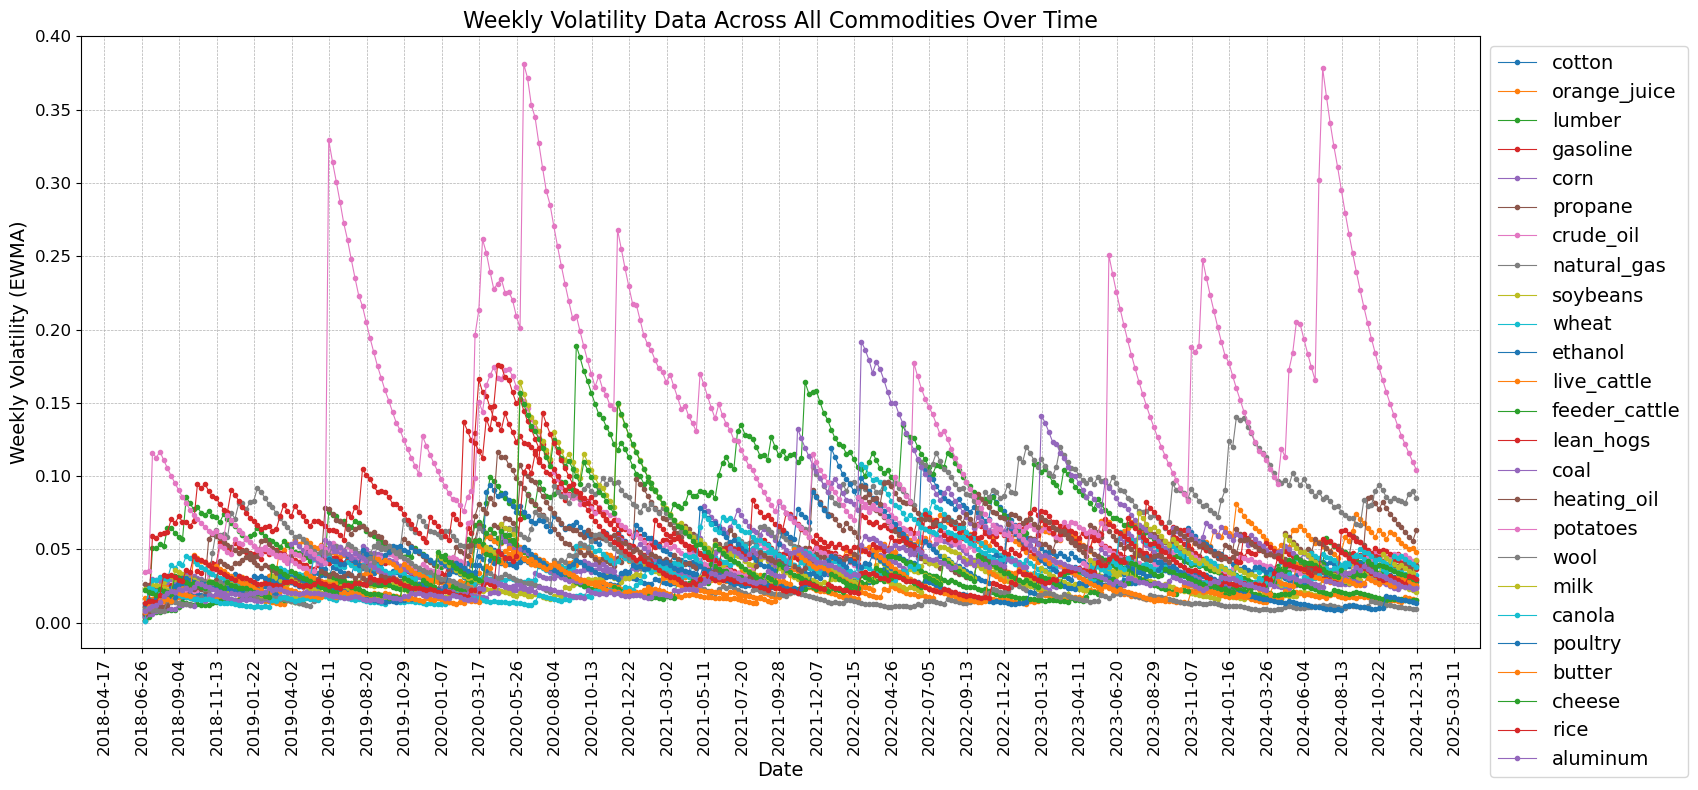

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

def plot_weekly_volatility_data_with_labels(data, labels, timestamps):
    """
    Plots the weekly volatility data for each commodity over time with every week shown on the x-axis and labels next to each curve.

    Parameters:
    - data: List of lists containing weekly volatility values for each commodity.
    - labels: List of commodity names.
    - timestamps: List of lists containing weekly dates for each commodity.
    """
    num_commodities = len(labels)

    # Set up the plot
    plt.figure(figsize=(15, 8))

    # Plot each commodity's volatility data over time
    for volatilities, dates, commodity in zip(data, timestamps, labels):
        # Convert date strings to datetime objects for plotting
        date_values = [datetime.strptime(date, "%Y-%m-%d") for date in dates]

        # Plot the commodity line
        plt.plot(date_values, volatilities, label=commodity, marker='o', markersize=3, linewidth=0.8)

    # Set plot labels and title with increased font sizes
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Weekly Volatility (EWMA)', fontsize=14)
    plt.title('Weekly Volatility Data Across All Commodities Over Time', fontsize=16)

    # Format the x-axis to show weekly intervals
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=10))  # Show every 10 weeks
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format as Year-Month-Day

    # Rotate x-axis labels and increase font size for ticks
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)

    # Add grid and adjust layout
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()

    # Add legend
    plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the plot
    plt.show()

# Usage
plot_weekly_volatility_data_with_labels(volatility_data, labels, timestamps)

